<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 825344 entries, 2026-01-26 09:00:00.014661840+00:00 to 2026-01-26 23:59:17.513585531+00:00
Data columns (total 73 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   ts_event       825344 non-null  datetime64[ns, UTC]
 1   rtype          825344 non-null  uint8              
 2   publisher_id   825344 non-null  uint16             
 3   instrument_id  825344 non-null  uint32             
 4   action         825344 non-null  object             
 5   side           825344 non-null  object             
 6   depth          825344 non-null  uint8              
 7   price          825344 non-null  float64            
 8   size           825344 non-null  uint32             
 9   flags          825344 non-null  uint8              
 10  ts_in_delta    825344 non-null  int32              
 11  sequence       825344 non-null  uint32             
 12  bid_px_00      82533

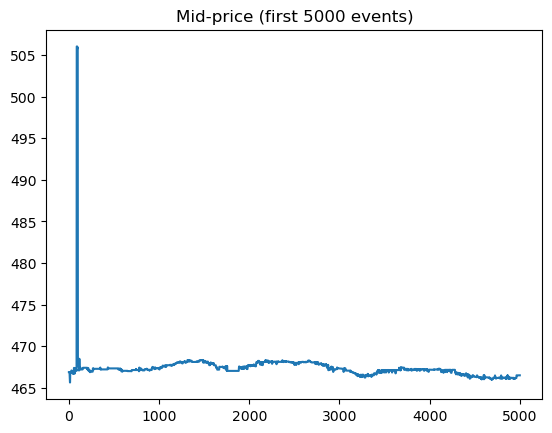

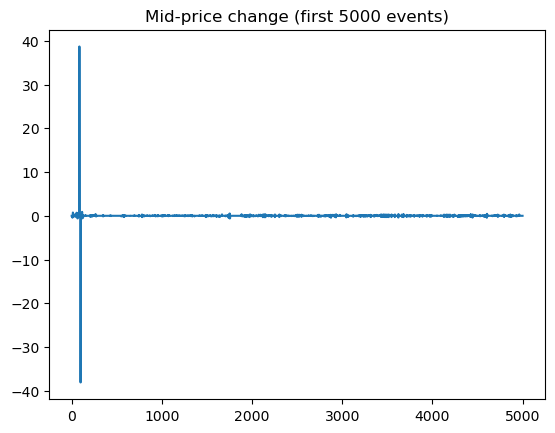

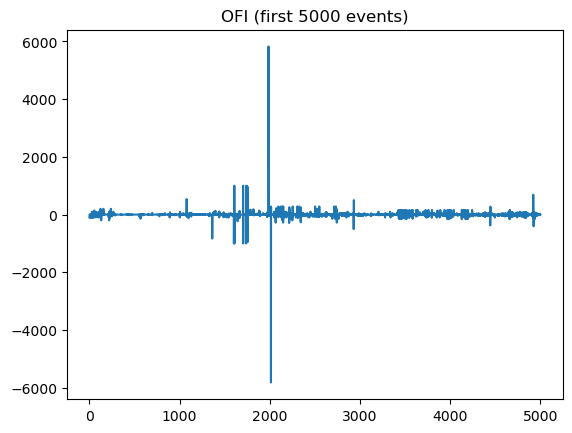

In [3]:
!pip install databento
import databento as db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\Users\USER\Desktop\MS -Thesis\Data\XNAS-20260128-UXEA6A9U6P\xnas-itch-20260126.mbp-10.dbn"

data = db.read_dbn(file_path)
df = data.to_df()

df.head()

df.columns
df.head()
df.info()

df = df.sort_values("ts_event")   #I sorted at this col because ts_event is when the event actually happened (ts_recv is when Databento received it)
df = df.dropna(subset=["bid_px_00","ask_px_00","bid_sz_00","ask_sz_00"])
df = df[df["bid_px_00"]<df["ask_px_00"]].copy()
df.head()

df["mid"] = (df["bid_px_00"] + df["ask_px_00"]) / 2
df["dmid"] = df["mid"].diff()

bid_px = df["bid_px_00"].values
ask_px = df["ask_px_00"].values
bid_sz = df["bid_sz_00"].values.astype(float)
ask_sz = df["ask_sz_00"].values.astype(float)

bid_px_prev = np.roll(bid_px, 1)
ask_px_prev = np.roll(ask_px, 1)
bid_sz_prev = np.roll(bid_sz, 1)
ask_sz_prev = np.roll(ask_sz, 1)

bid_px_prev[0] = bid_px[0]
ask_px_prev[0] = ask_px[0]
bid_sz_prev[0] = bid_sz[0]
ask_sz_prev[0] = ask_sz[0]

eb = np.where(bid_px == bid_px_prev,bid_sz - bid_sz_prev,np.where(bid_px > bid_px_prev, bid_sz, -bid_sz_prev))
ea = np.where(ask_px == ask_px_prev,ask_sz - ask_sz_prev,np.where(ask_px < ask_px_prev, ask_sz, -ask_sz_prev))
df["ofi"] = eb - ea

df["depth_best"] = df["bid_sz_00"] + df["ask_sz_00"]
df["inv_depth_best"] = 1.0 / df["depth_best"].replace(0, np.nan)

df = df.dropna(subset=["dmid", "ofi", "depth_best"]).copy()
df = df[df["depth_best"] > 0].copy()

X_raw = df[["dmid", "ofi", "inv_depth_best"]].to_numpy()
X_raw_small = X_raw[:50_000]

plt.figure()
plt.plot(df["mid"].iloc[:5000].values)
plt.title("Mid-price (first 5000 events)")
plt.show()

plt.figure()
plt.plot(df["dmid"].iloc[:5000].values)
plt.title("Mid-price change (first 5000 events)")
plt.show()

plt.figure()
plt.plot(df["ofi"].iloc[:5000].values)
plt.title("OFI (first 5000 events)")
plt.show()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X_raw_small)

In [4]:
import numpy as np

def hmm_parameters(pi, A, mus, Sigmas, tol=1e-8):
    pi = np.asarray(pi, dtype=float)
    A = np.asarray(A, dtype=float)
    mus = np.asarray(mus, dtype=float)
    Sigmas = np.asarray(Sigmas, dtype=float)
    if pi.ndim != 1:
        raise ValueError("pi must be a 1D array of shape (K,)")
    K = pi.shape[0]
    if A.shape != (K, K):
        raise ValueError("A must have shape (K, K)")
    if mus.ndim != 2:
        raise ValueError("mus must be a 2D array of shape (K, d)")
    if mus.shape[0] != K:
        raise ValueError("mus must have K rows")
    d = mus.shape[1]
    if Sigmas.shape != (K, d, d):
        raise ValueError("Sigmas must have shape (K, d, d)")
    if np.any(pi < 0):
        raise ValueError("pi must be nonnegative")
    if not np.isclose(pi.sum(), 1.0, atol=tol):
        raise ValueError("pi must sum to 1")
    if np.any(A < 0):
        raise ValueError("A must be nonnegative")
    if not np.allclose(A.sum(axis=1), 1.0, atol=tol):
        raise ValueError("Each row of A must sum to 1")
    eps = 1e-8
    for k in range(K):
        S = Sigmas[k]
        if not np.allclose(S, S.T, atol=tol):
            raise ValueError(f"Sigma[{k}] must be symmetric")
        try:
            np.linalg.cholesky(S + eps * np.eye(d))
        except np.linalg.LinAlgError:
            raise ValueError(f"Sigma[{k}] must be positive definite")
    if not np.all(np.isfinite(mus)):
        raise ValueError("mus contains NaN/inf")
    if not np.all(np.isfinite(Sigmas)):
        raise ValueError("Sigmas contains NaN/inf")
    return {"pi": pi, "A": A, "mus": mus, "Sigmas": Sigmas, "K": K, "d": d}

def prepare_gaussian_cache(mus, Sigmas, jitter=1e-9):
    mus = np.asarray(mus, dtype=float)
    Sigmas = np.asarray(Sigmas, dtype=float)
    K, d = mus.shape
    Ls = np.empty((K, d, d), dtype=float)
    logdets = np.empty(K, dtype=float)
    for k in range(K):
        S = Sigmas[k] + jitter * np.eye(d)
        L = np.linalg.cholesky(S)
        Ls[k] = L
        logdets[k] = 2.0 * np.sum(np.log(np.diag(L)))
    return Ls, logdets


def compute_logB(X, mus, Sigmas, jitter=1e-9):
    X = np.asarray(X, dtype=float)
    mus = np.asarray(mus, dtype=float)
    Sigmas = np.asarray(Sigmas, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be shape (T, d)")
    T, d = X.shape
    K, d2 = mus.shape
    if d != d2:
        raise ValueError("X and mus must have the same feature dimension")
    if Sigmas.shape != (K, d, d):
        raise ValueError("Sigmas must have shape (K, d, d)")
    Ls, logdets = prepare_gaussian_cache(mus, Sigmas, jitter=jitter)
    logB = np.empty((T, K), dtype=float)
    const = d * np.log(2.0 * np.pi)
    for k in range(K):
        XC = X - mus[k]
        Y = np.linalg.solve(Ls[k], XC.T).T
        quad = np.sum(Y * Y, axis=1)
        logB[:, k] = -0.5 * (const + logdets[k] + quad)
    return logB

def forward_filter_from_logB(logB, pi, A):
    logB = np.asarray(logB, dtype=float)
    pi = np.asarray(pi, dtype=float)
    A = np.asarray(A, dtype=float)
    T, K = logB.shape
    phi = np.zeros((T, K), dtype=float)
    c = np.zeros(T, dtype=float)
    logc = np.zeros(T, dtype=float)
    m0 = np.max(logB[0])
    g0 = np.exp(logB[0] - m0)
    alpha0 = pi * g0
    c0 = alpha0.sum()
    if c0 <= 0 or not np.isfinite(c0):
        raise ValueError("Forward filter failed at t=0")
    phi[0] = alpha0 / c0
    c[0] = c0
    logc[0] = m0 + np.log(c0)
    for t in range(1, T):
        phi_pred = phi[t - 1] @ A
        mt = np.max(logB[t])
        gt = np.exp(logB[t] - mt)
        alpha = phi_pred * gt
        ct = alpha.sum()
        if ct <= 0 or not np.isfinite(ct):
            raise ValueError(f"Forward filter failed at t={t}")
        phi[t] = alpha / ct
        c[t] = ct
        logc[t] = mt + np.log(ct)
    loglik = float(np.sum(logc))
    return phi, c, logc, loglik

def backward_normalized_from_logB(logB, A, c):
    logB = np.asarray(logB, dtype=float)
    A = np.asarray(A, dtype=float)
    c = np.asarray(c, dtype=float)
    T, K = logB.shape
    beta_bar = np.ones((T, K), dtype=float)
    for t in range(T - 2, -1, -1):
        m = np.max(logB[t + 1])
        g = np.exp(logB[t + 1] - m)
        tmp = g * beta_bar[t + 1]
        beta_bar[t] = (A @ tmp) / c[t + 1]
        if not np.all(np.isfinite(beta_bar[t])):
            raise ValueError(f"beta_bar contains NaN/inf at t={t}")
    return beta_bar

def smooth_gamma_xi_fast(X, pi, A, mus, Sigmas, jitter=1e-9):
    logB = compute_logB(X, mus, Sigmas, jitter=jitter)
    phi, c, logc, loglik = forward_filter_from_logB(logB, pi, A)
    beta_bar = backward_normalized_from_logB(logB, A, c)
    gamma = phi * beta_bar
    gamma = gamma / gamma.sum(axis=1, keepdims=True)
    T, K = logB.shape
    xi = np.zeros((T - 1, K, K), dtype=float)
    for t in range(T - 1):
        m = np.max(logB[t + 1])
        g = np.exp(logB[t + 1] - m)
        numer = (phi[t, :, None] * A) * (g[None, :] * beta_bar[t + 1][None, :])
        numer = numer / c[t + 1]
        Z = numer.sum()
        if Z <= 0 or not np.isfinite(Z):
            raise ValueError(f"xi normalization failed at t={t}")
        xi[t] = numer / Z
    return phi, beta_bar, gamma, xi, loglik

def m_step_updates(X, gamma, xi, cov_type="full", eps=1e-6):
    X = np.asarray(X, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    xi = np.asarray(xi, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be shape (T, d)")
    if gamma.ndim != 2:
        raise ValueError("gamma must be shape (T, K)")
    if xi.ndim != 3:
        raise ValueError("xi must be shape (T-1, K, K)")
    T, d = X.shape
    if gamma.shape[0] != T:
        raise ValueError("gamma first dimension must match T")
    K = gamma.shape[1]
    if xi.shape != (T - 1, K, K):
        raise ValueError("xi must be shape (T-1, K, K)")
    pi_new = gamma[0].copy()
    pi_new = pi_new / pi_new.sum()
    numer = xi.sum(axis=0)
    denom = gamma[:-1].sum(axis=0)
    if np.any(denom <= 0) or not np.all(np.isfinite(denom)):
        raise ValueError("A update failed")
    A_new = numer / denom[:, None]
    A_new = np.maximum(A_new, 0.0)
    A_new = A_new / A_new.sum(axis=1, keepdims=True)
    Nk = gamma.sum(axis=0)
    if np.any(Nk <= 0) or not np.all(np.isfinite(Nk)):
        raise ValueError("mu update failed")
    mus_new = (gamma.T @ X) / Nk[:, None]
    Sigmas_new = np.zeros((K, d, d), dtype=float)
    if cov_type == "full":
        for k in range(K):
            xc = X - mus_new[k]
            w = gamma[:, k][:, None]
            S = (w * xc).T @ xc
            S = S / Nk[k]
            S = S + eps * np.eye(d)
            Sigmas_new[k] = 0.5 * (S + S.T)
    elif cov_type == "diag":
        for k in range(K):
            xc = X - mus_new[k]
            w = gamma[:, k][:, None]
            v = (w * (xc ** 2)).sum(axis=0) / Nk[k]
            v = np.maximum(v, eps)
            Sigmas_new[k] = np.diag(v)
    else:
        raise ValueError("cov_type must be 'full' or 'diag'")
    return pi_new, A_new, mus_new, Sigmas_new

def baum_welch_em_fast(X, pi, A, mus, Sigmas, cov_type="full", eps=1e-6, tol=1e-4, max_iter=200, jitter=1e-9):
    X = np.asarray(X, dtype=float)
    pi = np.asarray(pi, dtype=float)
    A = np.asarray(A, dtype=float)
    mus = np.asarray(mus, dtype=float)
    Sigmas = np.asarray(Sigmas, dtype=float)
    _ = hmm_parameters(pi, A, mus, Sigmas)
    loglik_hist = []
    for it in range(max_iter):
        phi, beta_bar, gamma, xi, loglik = smooth_gamma_xi_fast(X, pi, A, mus, Sigmas, jitter=jitter)
        loglik_hist.append(loglik)
        pi_new, A_new, mus_new, Sigmas_new = m_step_updates(X, gamma, xi, cov_type=cov_type, eps=eps)
        if it >= 1:
            improvement = loglik_hist[-1] - loglik_hist[-2]
            if improvement < tol:
                pi, A, mus, Sigmas = pi_new, A_new, mus_new, Sigmas_new
                break
        pi, A, mus, Sigmas = pi_new, A_new, mus_new, Sigmas_new
    _ = hmm_parameters(pi, A, mus, Sigmas)
    return {
        "pi": pi,
        "A": A,
        "mus": mus,
        "Sigmas": Sigmas,
        "loglik_hist": np.asarray(loglik_hist, dtype=float),
    }

def num_params(K, d, cov_type="full"):
    K = int(K)
    d = int(d)
    if K <= 0 or d <= 0:
        raise ValueError("K and d must be positive")
    if cov_type not in ("full", "diag"):
        raise ValueError("cov_type must be 'full' or 'diag'")
    p_pi = K - 1
    p_A = K * (K - 1)
    p_mu = K * d
    if cov_type == "full":
        p_Sigma = K * (d * (d + 1) // 2)
    else:
        p_Sigma = K * d
    return int(p_pi + p_A + p_mu + p_Sigma)

def aic(loglik, p):
    loglik = float(loglik)
    p = int(p)
    if not np.isfinite(loglik):
        raise ValueError("loglik must be finite")
    if p < 0:
        raise ValueError("p must be nonnegative")
    return float(-2.0 * loglik + 2.0 * p)

def bic(loglik, p, T):
    loglik = float(loglik)
    p = int(p)
    T = int(T)
    if not np.isfinite(loglik):
        raise ValueError("loglik must be finite")
    if p < 0:
        raise ValueError("p must be nonnegative")
    if T <= 1:
        raise ValueError("T must be >= 2")
    return float(-2.0 * loglik + p * np.log(float(T)))

def _random_stochastic_matrix(K, rng, minval=1e-6):
    M = rng.random((K, K)) + minval
    M = M / M.sum(axis=1, keepdims=True)
    return M

def _init_gaussian_params_from_data(X, K, cov_type="full", eps=1e-6, rng=None):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be shape (T, d)")
    T, d = X.shape
    if T < 2:
        raise ValueError("Need T >= 2")
    if K <= 0:
        raise ValueError("K must be positive")
    if cov_type not in ("full", "diag"):
        raise ValueError("cov_type must be 'full' or 'diag'")
    if rng is None:
        rng = np.random.default_rng()
    pi0 = np.ones(K, dtype=float) / float(K)
    A0 = _random_stochastic_matrix(K, rng)
    idx = rng.integers(low=0, high=T, size=K)
    mus0 = X[idx].copy()
    Xc = X - X.mean(axis=0, keepdims=True)
    if cov_type == "full":
        S = (Xc.T @ Xc) / max(T - 1, 1)
        S = S + eps * np.eye(d)
        Sigmas0 = np.repeat(S[None, :, :], K, axis=0)
    else:
        v = (Xc ** 2).mean(axis=0)
        v = np.maximum(v, eps)
        Sigmas0 = np.repeat(np.diag(v)[None, :, :], K, axis=0)
    return pi0, A0, mus0, Sigmas0

def fit_best_of_restarts_fast(
    X,
    K,
    cov_type="full",
    R=10,
    eps=1e-6,
    tol=1e-4,
    max_iter=200,
    jitter=1e-9,
    random_state=0,
    verbose=True,
):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be shape (T, d)")
    T, d = X.shape
    if T < 2:
        raise ValueError("Need T >= 2")
    if R <= 0:
        raise ValueError("R must be positive")
    rng = np.random.default_rng(random_state)
    best_model = None
    best_loglik = -np.inf
    best_r = None
    n_fail = 0
    fail_log = []
    for r in range(R):
        if verbose:
            print(f"Fitting K={K}, restart={r+1}/{R} ...")
        rng_r = np.random.default_rng(rng.integers(0, 2**32 - 1))
        pi0, A0, mus0, Sigmas0 = _init_gaussian_params_from_data(
            X,
            K,
            cov_type=cov_type,
            eps=eps,
            rng=rng_r,
        )
        try:
            model = baum_welch_em_fast(
                X,
                pi0,
                A0,
                mus0,
                Sigmas0,
                cov_type=cov_type,
                eps=eps,
                tol=tol,
                max_iter=max_iter,
                jitter=jitter,
            )
            final_loglik = float(model["loglik_hist"][-1]) if len(model["loglik_hist"]) > 0 else -np.inf
        except Exception as e:
            n_fail += 1
            msg = f"restart={r} {type(e).__name__}: {str(e)[:120]}"
            fail_log.append(msg)
            if verbose:
                print("[FAIL]", msg)
            continue
        if np.isfinite(final_loglik) and final_loglik > best_loglik:
            best_loglik = final_loglik
            best_model = model
            best_r = r
    if verbose:
        print(f"K={K}: failures {n_fail}/{R}")
    if best_model is None:
        preview = "\n".join(fail_log[:5])
        raise RuntimeError(
            "All EM restarts failed. "
            f"First failures:\n{preview}\n"
            "Try increasing eps/jitter, using diag cov, reducing K, or better initialization."
        )
    best_model = dict(best_model)
    best_model["best_loglik"] = float(best_loglik)
    best_model["restart_index"] = int(best_r)
    best_model["n_fail"] = int(n_fail)
    best_model["R"] = int(R)
    best_model["fail_log"] = fail_log
    return best_model

def score_over_K_fast(
    X,
    K_grid,
    cov_type="full",
    R=10,
    eps=1e-6,
    tol=1e-4,
    max_iter=200,
    jitter=1e-9,
    random_state=0,
    verbose=True,
):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be shape (T, d)")
    T, d = X.shape
    if T < 2:
        raise ValueError("Need T >= 2")
    K_grid = list(K_grid)
    if len(K_grid) == 0:
        raise ValueError("K_grid must be non-empty")
    results = []
    models = {}
    for K in K_grid:
        K = int(K)
        if K <= 0:
            raise ValueError("All K must be positive")
        best_model = fit_best_of_restarts_fast(
            X,
            K,
            cov_type=cov_type,
            R=R,
            eps=eps,
            tol=tol,
            max_iter=max_iter,
            jitter=jitter,
            random_state=(random_state + 1000 * K),
            verbose=verbose,
        )
        loglik = float(best_model["best_loglik"])
        p = num_params(K, d, cov_type=cov_type)
        row = {
            "K": K,
            "T": int(T),
            "d": int(d),
            "cov_type": cov_type,
            "p": int(p),
            "loglik": float(loglik),
            "AIC": aic(loglik, p),
            "BIC": bic(loglik, p, T),
            "best_restart": int(best_model["restart_index"]),
            "n_iters": int(len(best_model["loglik_hist"])),
            "failures": int(best_model["n_fail"]),
            "R": int(best_model["R"]),
        }
        results.append(row)
        models[K] = best_model
    return results, models

Fitting K=1, restart=1/5 ...
Fitting K=1, restart=2/5 ...
Fitting K=1, restart=3/5 ...
Fitting K=1, restart=4/5 ...
Fitting K=1, restart=5/5 ...
K=1: failures 0/5
Fitting K=2, restart=1/5 ...
Fitting K=2, restart=2/5 ...
Fitting K=2, restart=3/5 ...
Fitting K=2, restart=4/5 ...
Fitting K=2, restart=5/5 ...
K=2: failures 0/5
Fitting K=3, restart=1/5 ...
Fitting K=3, restart=2/5 ...
Fitting K=3, restart=3/5 ...
Fitting K=3, restart=4/5 ...
Fitting K=3, restart=5/5 ...
K=3: failures 0/5
Fitting K=4, restart=1/5 ...
Fitting K=4, restart=2/5 ...
Fitting K=4, restart=3/5 ...
Fitting K=4, restart=4/5 ...
Fitting K=4, restart=5/5 ...
K=4: failures 0/5
Fitting K=5, restart=1/5 ...
Fitting K=5, restart=2/5 ...
Fitting K=5, restart=3/5 ...
Fitting K=5, restart=4/5 ...
Fitting K=5, restart=5/5 ...
K=5: failures 0/5
Fitting K=6, restart=1/5 ...
Fitting K=6, restart=2/5 ...
Fitting K=6, restart=3/5 ...
Fitting K=6, restart=4/5 ...
Fitting K=6, restart=5/5 ...
K=6: failures 0/5
Fitting K=7, restart=1

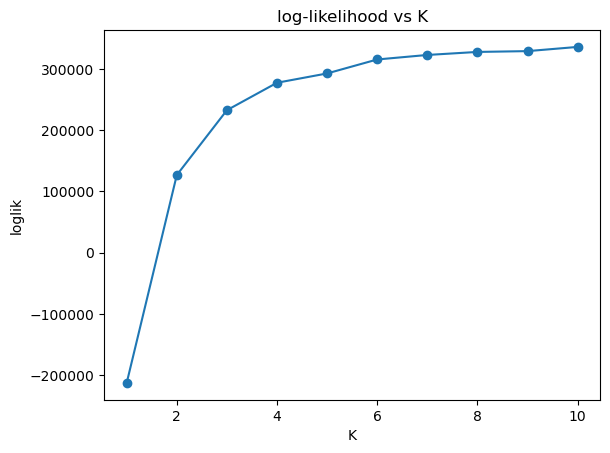

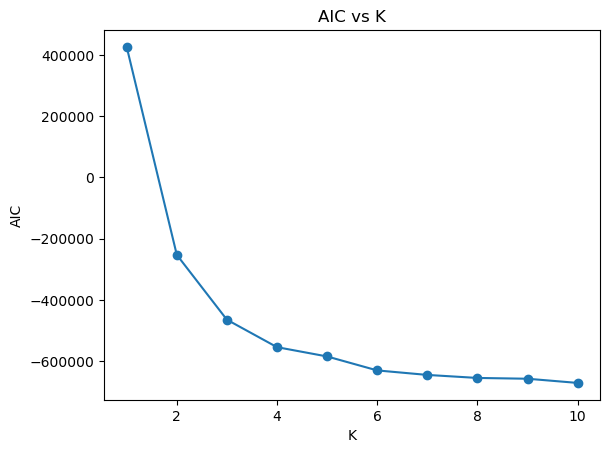

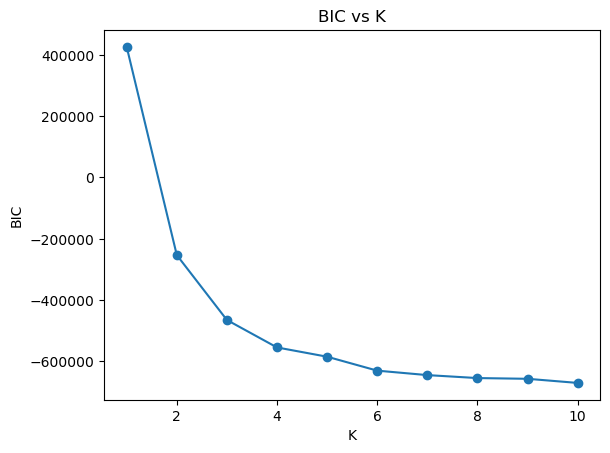

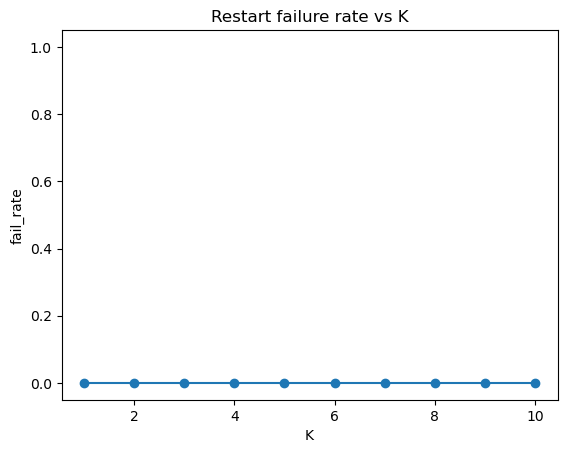

AIC-best K = 10
BIC-best K = 10
    K         loglik            AIC            BIC  n_iters  failures  R  \
0   1 -212840.779981  425693.559961  425746.478631        3         0  5   
1   2  126595.627499 -253161.254997 -253028.958323       20         0  5   
2   3  232479.544745 -464907.089490 -464677.775255       34         0  5   
3   4  277306.312256 -554534.624511 -554190.653158       45         0  5   
4   5  292499.894324 -584891.788649 -584415.520621       50         0  5   
5   6  315304.501405 -630467.002809 -629840.798551       49         0  5   
6   7  322672.916378 -645165.832756 -644372.052710       50         0  5   
7   8  327626.178221 -655030.356442 -654051.361053       50         0  5   
8   9  328944.156601 -657620.313203 -656438.462913       50         0  5   
9  10  335804.203248 -671290.406496 -669888.061749       50         0  5   

   fail_rate  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  
6        0.0  
7        0.

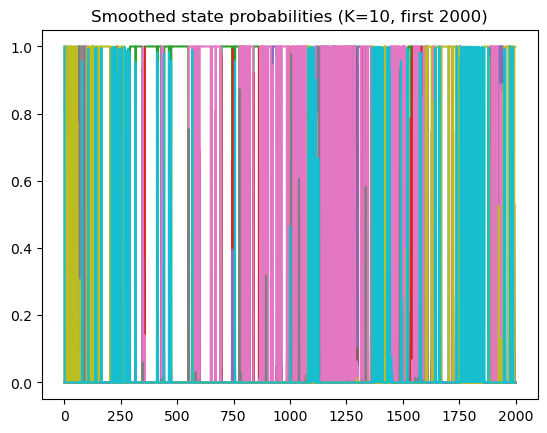

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

X_small = X[:50000]
K_grid = list(range(1, 11))

results, models = score_over_K_fast(
    X_small,
    K_grid,
    cov_type="diag",
    R=5,
    max_iter=50,
    tol=1e-4,
    eps=1e-6,
    jitter=1e-9,
    random_state=0,
    verbose=True,
)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("K").reset_index(drop=True)
results_df["fail_rate"] = results_df["failures"] / results_df["R"]

plt.figure()
plt.plot(results_df["K"], results_df["loglik"], marker="o")
plt.title("log-likelihood vs K")
plt.xlabel("K")
plt.ylabel("loglik")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["AIC"], marker="o")
plt.title("AIC vs K")
plt.xlabel("K")
plt.ylabel("AIC")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["BIC"], marker="o")
plt.title("BIC vs K")
plt.xlabel("K")
plt.ylabel("BIC")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["fail_rate"], marker="o")
plt.title("Restart failure rate vs K")
plt.xlabel("K")
plt.ylabel("fail_rate")
plt.ylim(-0.05, 1.05)
plt.show()

K_aic = int(results_df.loc[results_df["AIC"].idxmin(), "K"])
K_bic = int(results_df.loc[results_df["BIC"].idxmin(), "K"])
print("AIC-best K =", K_aic)
print("BIC-best K =", K_bic)
cols = ["K", "loglik", "AIC", "BIC", "n_iters", "failures", "R", "fail_rate"]
print(results_df[cols])
best_K = K_bic
best_model = models[best_K]

phi, beta_bar, gamma, xi, loglik = smooth_gamma_xi_fast(
    X_small,
    best_model["pi"],
    best_model["A"],
    best_model["mus"],
    best_model["Sigmas"],
)

plt.figure()
plt.plot(gamma[:2000])
plt.title(f"Smoothed state probabilities (K={best_K}, first 2000)")
plt.show()

In [7]:
import os
import json
import joblib
import numpy as np
import pandas as pd

save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k"

os.makedirs(save_dir, exist_ok=True)

results_df.to_csv(os.path.join(save_dir, "results_summary.csv"), index=False)

joblib.dump(models, os.path.join(save_dir, "models.joblib"))

np.save(os.path.join(save_dir, "X_small.npy"), X_small)

np.save(os.path.join(save_dir, "X.npy"), X)

joblib.dump(scaler, os.path.join(save_dir, "scaler.joblib"))

joblib.dump(best_model, os.path.join(save_dir, f"best_model_K_{best_K}.joblib"))

np.save(os.path.join(save_dir, f"phi_K_{best_K}.npy"), phi)
np.save(os.path.join(save_dir, f"beta_bar_K_{best_K}.npy"), beta_bar)
np.save(os.path.join(save_dir, f"gamma_K_{best_K}.npy"), gamma)
np.save(os.path.join(save_dir, f"xi_K_{best_K}.npy"), xi)

metadata = {
    "dimension": int(X_small.shape[1]),
    "n_obs_used": int(X_small.shape[0]),
    "cov_type": "diag",
    "K_grid": [int(k) for k in K_grid],
    "R": 5,
    "max_iter": 50,
    "tol": 1e-4,
    "eps": 1e-6,
    "jitter": 1e-9,
    "random_state": 0,
    "AIC_best_K": int(K_aic),
    "BIC_best_K": int(K_bic),
    "chosen_best_K": int(best_K),
    "final_loglik_best_K": float(loglik),
}

with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Saved everything to:\n{save_dir}")

Saved everything to:
C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k


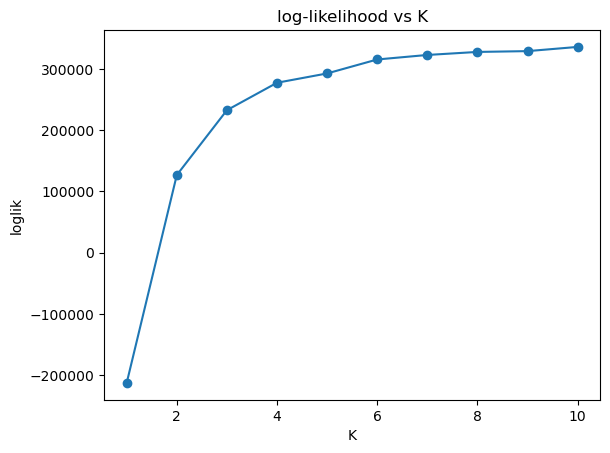

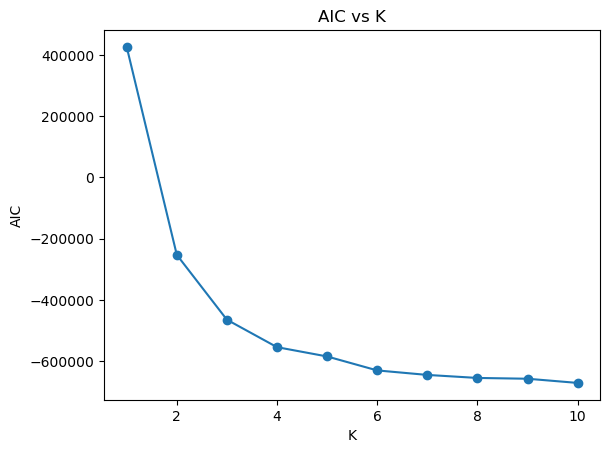

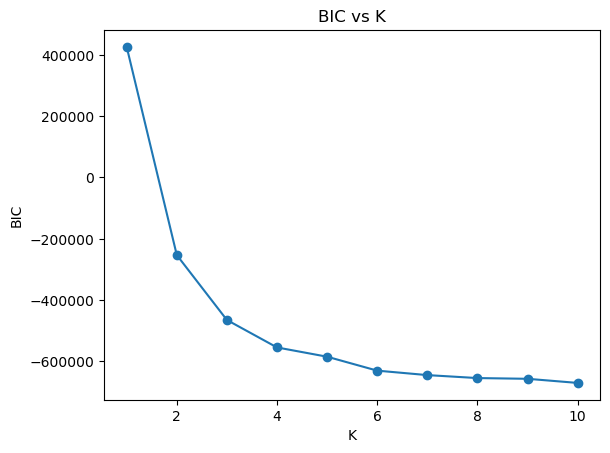

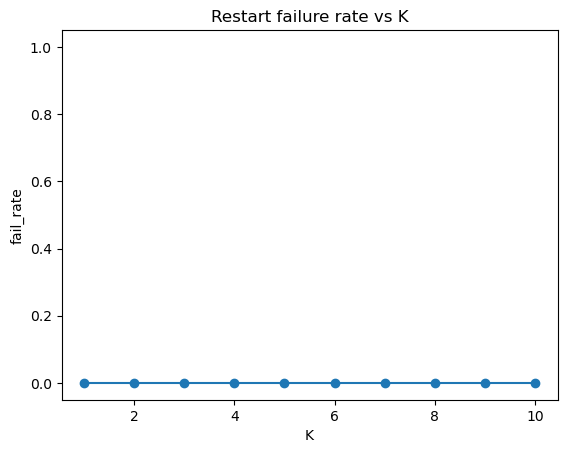

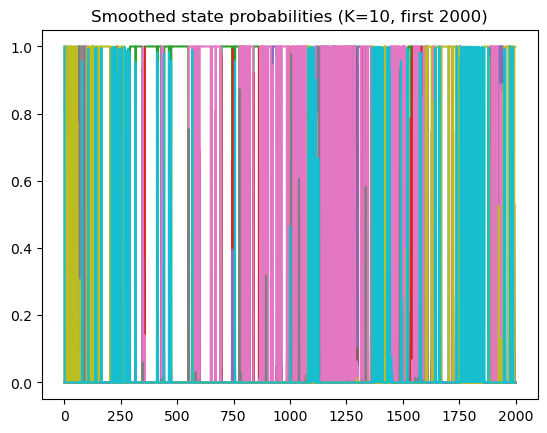

In [8]:
plt.figure()
plt.plot(results_df["K"], results_df["loglik"], marker="o")
plt.title("log-likelihood vs K")
plt.xlabel("K")
plt.ylabel("loglik")
plt.savefig(os.path.join(save_dir, "loglik_vs_K.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["AIC"], marker="o")
plt.title("AIC vs K")
plt.xlabel("K")
plt.ylabel("AIC")
plt.savefig(os.path.join(save_dir, "AIC_vs_K.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["BIC"], marker="o")
plt.title("BIC vs K")
plt.xlabel("K")
plt.ylabel("BIC")
plt.savefig(os.path.join(save_dir, "BIC_vs_K.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["fail_rate"], marker="o")
plt.title("Restart failure rate vs K")
plt.xlabel("K")
plt.ylabel("fail_rate")
plt.ylim(-0.05, 1.05)
plt.savefig(os.path.join(save_dir, "failure_rate_vs_K.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(gamma[:2000])
plt.title(f"Smoothed state probabilities (K={best_K}, first 2000)")
plt.savefig(os.path.join(save_dir, f"gamma_first2000_K_{best_K}.png"), dpi=200, bbox_inches="tight")
plt.show()

Fitting K=11, restart=1/5 ...
Fitting K=11, restart=2/5 ...
Fitting K=11, restart=3/5 ...
Fitting K=11, restart=4/5 ...
Fitting K=11, restart=5/5 ...
K=11: failures 0/5
Fitting K=12, restart=1/5 ...
Fitting K=12, restart=2/5 ...
Fitting K=12, restart=3/5 ...
Fitting K=12, restart=4/5 ...
Fitting K=12, restart=5/5 ...
K=12: failures 0/5
Fitting K=13, restart=1/5 ...
Fitting K=13, restart=2/5 ...
Fitting K=13, restart=3/5 ...
Fitting K=13, restart=4/5 ...
Fitting K=13, restart=5/5 ...
K=13: failures 0/5
Fitting K=14, restart=1/5 ...
Fitting K=14, restart=2/5 ...
Fitting K=14, restart=3/5 ...
Fitting K=14, restart=4/5 ...
Fitting K=14, restart=5/5 ...
K=14: failures 0/5
Fitting K=15, restart=1/5 ...
Fitting K=15, restart=2/5 ...
Fitting K=15, restart=3/5 ...
Fitting K=15, restart=4/5 ...
Fitting K=15, restart=5/5 ...
K=15: failures 0/5
Fitting K=16, restart=1/5 ...
Fitting K=16, restart=2/5 ...
Fitting K=16, restart=3/5 ...
Fitting K=16, restart=4/5 ...
Fitting K=16, restart=5/5 ...
K=16:

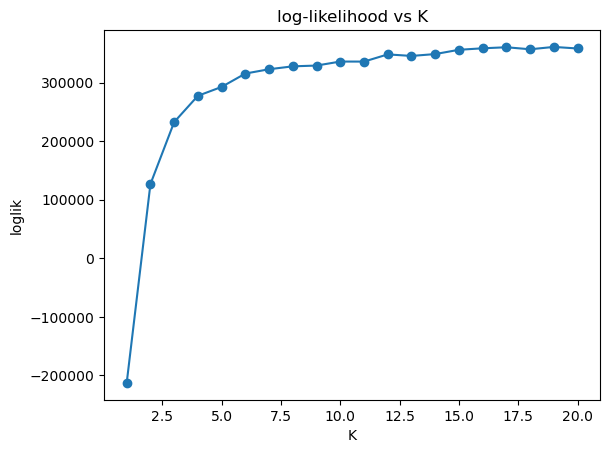

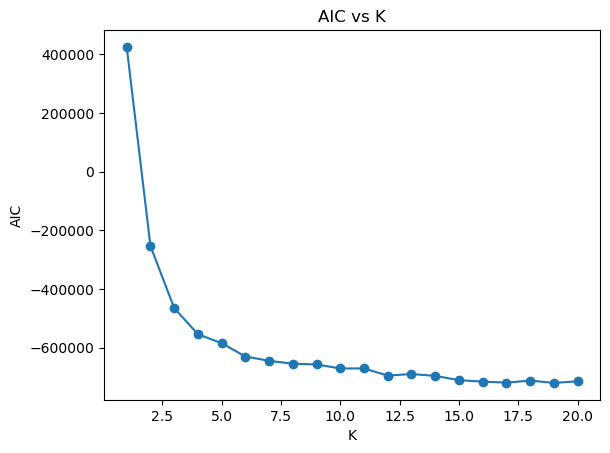

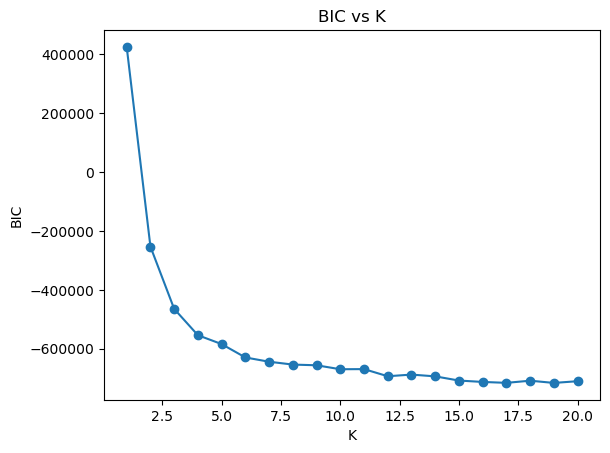

Updated results saved.


In [9]:
import os
import joblib
import numpy as np
import pandas as pd

save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k"

results_df_old = pd.read_csv(os.path.join(save_dir, "results_summary.csv"))
models_old = joblib.load(os.path.join(save_dir, "models.joblib"))
X_small = np.load(os.path.join(save_dir, "X_small.npy"))

K_grid_new = list(range(11, 21))

results_new, models_new = score_over_K_fast(
    X_small,
    K_grid_new,
    cov_type="diag",
    R=5,
    max_iter=50,
    tol=1e-4,
    eps=1e-6,
    jitter=1e-9,
    random_state=0,
    verbose=True,
)

results_df_new = pd.DataFrame(results_new)
results_df_new = results_df_new.sort_values("K").reset_index(drop=True)

results_df_new["fail_rate"] = results_df_new["failures"] / results_df_new["R"]

results_df_all = pd.concat([results_df_old, results_df_new], ignore_index=True)
results_df_all = results_df_all.sort_values("K").reset_index(drop=True)

models_all = {**models_old, **models_new}

K_aic = int(results_df_all.loc[results_df_all["AIC"].idxmin(), "K"])
K_bic = int(results_df_all.loc[results_df_all["BIC"].idxmin(), "K"])

print("AIC-best K =", K_aic)
print("BIC-best K =", K_bic)

plt.figure()
plt.plot(results_df_all["K"], results_df_all["loglik"], marker="o")
plt.title("log-likelihood vs K")
plt.xlabel("K")
plt.ylabel("loglik")
plt.show()

plt.figure()
plt.plot(results_df_all["K"], results_df_all["AIC"], marker="o")
plt.title("AIC vs K")
plt.xlabel("K")
plt.ylabel("AIC")
plt.show()

plt.figure()
plt.plot(results_df_all["K"], results_df_all["BIC"], marker="o")
plt.title("BIC vs K")
plt.xlabel("K")
plt.ylabel("BIC")
plt.show()

results_df_all.to_csv(os.path.join(save_dir, "results_summary.csv"), index=False)
joblib.dump(models_all, os.path.join(save_dir, "models.joblib"))
print("Updated results saved.")

In [10]:
import os
save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k"
for f in os.listdir(save_dir):
    print(f)

AIC_vs_K.png
best_model_K_10.joblib
beta_bar_K_10.npy
BIC_vs_K.png
failure_rate_vs_K.png
gamma_first2000_K_10.png
gamma_K_10.npy
loglik_vs_K.png
metadata.json
models.joblib
phi_K_10.npy
results_summary.csv
scaler.joblib
X.npy
xi_K_10.npy
X_small.npy


In [12]:
import os
import joblib
save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k"
models = joblib.load(os.path.join(save_dir, "models.joblib"))
print(sorted(models.keys()))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [13]:
import os
import numpy as np
import joblib

save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k"

models = joblib.load(os.path.join(save_dir, "models.joblib"))
X_small = np.load(os.path.join(save_dir, "X_small.npy"))
best_K = 19
best_model = models[best_K]

#Compute smoothing outputs
phi, beta_bar, gamma, xi, loglik = smooth_gamma_xi_fast(
    X_small,
    best_model["pi"],
    best_model["A"],
    best_model["mus"],
    best_model["Sigmas"],
)

#Save
np.save(os.path.join(save_dir, "phi_K_19.npy"), phi)
np.save(os.path.join(save_dir, "beta_bar_K_19.npy"), beta_bar)
np.save(os.path.join(save_dir, "gamma_K_19.npy"), gamma)
np.save(os.path.join(save_dir, "xi_K_19.npy"), xi)

joblib.dump(best_model, os.path.join(save_dir, "best_model_K_19.joblib"))

print("Saved K=19 outputs.")

Saved K=19 outputs.
